# QDoRA BF16 magnitude vs forced FP32 magnitude



In [11]:
from __future__ import annotations

import hashlib
import json
import math
import os
import re
import struct
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yaml
from dotenv import load_dotenv
from huggingface_hub import HfApi
from IPython.display import display

load_dotenv()

HF_ENDPOINT = "https://huggingface.co".rstrip("/")
HF_TOKEN = os.environ.get("HF_TOKEN") # Required by llama

REPO_ID = "anon-review-12345/dora-reproducibility-study"
REVISION = "main"

RUNS = {
    "bf16-native":    "qdora-diagnostic-run/control-bf16",
    "fp32-magnitude": "qdora-diagnostic-run/forced-fp32",
}

EXPECTED_MAGNITUDE_TENSORS = 160
ADAPTER_FILE = "adapter_model.safetensors"
SNAPSHOT_DIR = "analysis_snapshots"

# Every magnitude tensor is fetched in full (~1.6 MB in BF16, ~3.1 MB in FP32 per
# snapshot). The LoRA A/B families are ~113 MB per snapshot and only serve as a
# control that the run trained at all, so they are hashed on a fixed layer sample.
# Set LORA_HASH_LAYERS = None to hash every layer instead.
LORA_HASH_LAYERS = (0, 15, 31)

OUT = Path("outputs/")
OUT.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUT.resolve())


Output directory: /teamspace/studios/this_studio/dora-case-studies/notebooks/outputs


## Remote access


In [12]:
SESSION = requests.Session()
# The Hub serves the larger metrics files brotli-encoded, and some urllib3/brotli
# builds fail to decode those streams; ask for them uncompressed instead.
SESSION.headers["Accept-Encoding"] = "identity"
if HF_TOKEN:
    SESSION.headers["Authorization"] = f"Bearer {HF_TOKEN}"

REQUEST_TIMEOUT = 60
REQUEST_RETRIES = 3


def http_get(repo_id, path, revision=REVISION, headers=None):
    url = f"{HF_ENDPOINT}/{repo_id}/resolve/{revision}/{path}"
    last_error = None
    for _ in range(REQUEST_RETRIES):
        try:
            response = SESSION.get(url, headers=headers, timeout=REQUEST_TIMEOUT)
            response.raise_for_status()
            return response
        except requests.RequestException as error:
            last_error = error
    raise RuntimeError(f"GET failed after {REQUEST_RETRIES} attempts: {url}") from last_error


def read_remote_json(repo_id, path, revision=REVISION):
    return json.loads(http_get(repo_id, path, revision).text)


def read_remote_yaml(repo_id, path, revision=REVISION):
    return yaml.safe_load(http_get(repo_id, path, revision).text)


def read_remote_jsonl(repo_id, path, revision=REVISION):
    text = http_get(repo_id, path, revision).text
    return [json.loads(line) for line in text.splitlines() if line.strip()]


class RemoteSafetensors:
    """Random access into a safetensors file on the Hub, via HTTP range requests.

    Only the header and the byte ranges of the tensors actually requested are
    transferred; nothing is written to disk. Raw bytes are returned as stored so
    that hashes match the ones a local reader would compute.
    """

    def __init__(self, repo_id, path, revision=REVISION):
        self.repo_id = repo_id
        self.path = path
        self.revision = revision
        header_length = struct.unpack("<Q", self._read(0, 8))[0]
        self.header = json.loads(self._read(8, 8 + header_length).decode("utf-8"))
        self.header.pop("__metadata__", None)
        self.data_start = 8 + header_length

    def _read(self, start, end):
        response = http_get(
            self.repo_id, self.path, self.revision,
            headers={"Range": f"bytes={start}-{end - 1}"},
        )
        if response.status_code != 206:
            raise RuntimeError(
                f"Server ignored the range request for {self.repo_id}/{self.path}"
            )
        return response.content

    def keys(self):
        return self.header.keys()

    def get_record(self, name):
        entry = self.header[name]
        start, end = entry["data_offsets"]
        raw = self._read(self.data_start + start, self.data_start + end)
        return {
            "dtype": entry["dtype"],
            "shape": tuple(entry["shape"]),
            "raw": raw,
            "sha256": hashlib.sha256(raw).hexdigest(),
        }


HF_API = HfApi(token=HF_TOKEN)

try:
    REPO_FILES = set(HF_API.list_repo_files(REPO_ID, revision=REVISION))
except Exception as error:
    raise RuntimeError(
        f"Could not list {REPO_ID}@{REVISION}. Gated repositories need a valid "
        "HF_TOKEN in the environment or in .env."
    ) from error

missing = {
    run: f"{repo_dir}/resolved_config.yaml"
    for run, repo_dir in RUNS.items()
    if f"{repo_dir}/resolved_config.yaml" not in REPO_FILES
}
assert not missing, f"Run directories not found in the repo; update RUNS above: {missing}"

print(f"{REPO_ID}@{REVISION}: {len(REPO_FILES):,} files listed (no download yet)")


anon-review-12345/dora-reproducibility-study@main: 797 files listed (no download yet)


## 1. Verify that the intervention is controlled



In [13]:
MISSING = "<MISSING>"


def flatten_config(value, prefix=""):
    if isinstance(value, dict):
        result = {}
        for key, child in value.items():
            child_prefix = f"{prefix}.{key}" if prefix else str(key)
            result.update(flatten_config(child, child_prefix))
        return result
    if isinstance(value, list):
        return {prefix: json.dumps(value, sort_keys=True)}
    return {prefix: value}


configs = {
    run: read_remote_yaml(REPO_ID, f"{repo_dir}/resolved_config.yaml")
    for run, repo_dir in RUNS.items()
}
flat = {run: flatten_config(cfg) for run, cfg in configs.items()}
all_keys = sorted(set().union(*(set(values) for values in flat.values())))

config_diff_rows = []
for key in all_keys:
    left = flat["bf16-native"].get(key, MISSING)
    right = flat["fp32-magnitude"].get(key, MISSING)
    if left != right:
        config_diff_rows.append({
            "config_key": key,
            "bf16-native": left,
            "fp32-magnitude": right,
        })

config_diffs = pd.DataFrame(config_diff_rows)
display(config_diffs)
config_diffs.to_csv(OUT / "config_differences.csv", index=False)


,config_key,bf16-native,fp32-magnitude
0,adapter.magnitude_dtype,<MISSING>,fp32
1,experiment.output_dir,outputs/meta-llama-3-8b-qdora-43-bf16,outputs/meta-llama-3-8b-qdora-43-fp32


## 2. Discover every actual snapshot

The snapshot directories are enumerated from the repository file listing, and the
step of each one comes from its `snapshot_metadata.json` (falling back to the
`step_<n>` suffix in the directory name).


In [14]:
def snapshot_step(repo_dir, snapshot_name):
    metadata_path = f"{repo_dir}/{SNAPSHOT_DIR}/{snapshot_name}/snapshot_metadata.json"
    metadata = read_remote_json(REPO_ID, metadata_path) if metadata_path in REPO_FILES else {}
    if metadata.get("step") is not None:
        return int(metadata["step"])
    match = re.search(r"step_(\d+)", snapshot_name)
    if match is None:
        raise ValueError(f"Cannot determine snapshot step: {metadata_path}")
    return int(match.group(1))


def discover_all_snapshots(repo_dir):
    prefix = f"{repo_dir}/{SNAPSHOT_DIR}/"
    names = sorted({
        path[len(prefix):].split("/")[0]
        for path in REPO_FILES
        if path.startswith(prefix) and "/" in path[len(prefix):]
    })
    names = [
        name for name in names
        if f"{prefix}{name}/{ADAPTER_FILE}" in REPO_FILES
    ]
    assert names, f"No snapshots containing {ADAPTER_FILE}: {REPO_ID}/{prefix}"

    step_to_names = {}
    for name in names:
        step_to_names.setdefault(snapshot_step(repo_dir, name), []).append(name)
    duplicates = {step: found for step, found in step_to_names.items() if len(found) > 1}
    if duplicates:
        raise ValueError(f"Duplicate snapshot steps found: {duplicates}")

    return [
        {"name": name, "step": step, "path": f"{prefix}{name}/{ADAPTER_FILE}"}
        for step, (name,) in sorted(step_to_names.items())
    ]


SNAPSHOTS = {run: discover_all_snapshots(repo_dir) for run, repo_dir in RUNS.items()}
step_sets = {run: [s["step"] for s in snapshots] for run, snapshots in SNAPSHOTS.items()}
assert step_sets["bf16-native"] == step_sets["fp32-magnitude"], (
    f"The paired runs do not have the same saved steps: {step_sets}"
)

inventory = pd.DataFrame([
    {
        "run": run,
        "step": snapshot["step"],
        "snapshot": snapshot["name"],
        "path": f"{REPO_ID}/{snapshot['path']}",
    }
    for run, snapshots in SNAPSHOTS.items()
    for snapshot in snapshots
])
display(inventory)
inventory.to_csv(OUT / "snapshot_inventory.csv", index=False)


,run,step,snapshot,path
0,bf16-native,10,fraction_0.005_step_10,anon-review-12345/dora-reproducibility-study/q...
1,bf16-native,50,fraction_0.025_step_50,anon-review-12345/dora-reproducibility-study/q...
2,bf16-native,100,fraction_0.05_step_100,anon-review-12345/dora-reproducibility-study/q...
3,bf16-native,200,fraction_0.1_step_200,anon-review-12345/dora-reproducibility-study/q...
4,bf16-native,500,fraction_0.25_step_500,anon-review-12345/dora-reproducibility-study/q...
5,bf16-native,1000,fraction_0.5_step_1000,anon-review-12345/dora-reproducibility-study/q...
6,bf16-native,2000,final_step_2000,anon-review-12345/dora-reproducibility-study/q...
7,fp32-magnitude,10,fraction_0.005_step_10,anon-review-12345/dora-reproducibility-study/q...
8,fp32-magnitude,50,fraction_0.025_step_50,anon-review-12345/dora-reproducibility-study/q...
9,fp32-magnitude,100,fraction_0.05_step_100,anon-review-12345/dora-reproducibility-study/q...


## 3. Fingerprint raw tensors


In [15]:
KEY_RE = re.compile(r"layers\.(\d+)\.(?:self_attn|mlp)\.([a-z_]+proj)\b")


def tensor_family(key):
    if ".lora_A" in key:
        return "lora_A"
    if ".lora_B" in key:
        return "lora_B"
    if "lora_magnitude_vector" in key or ".magnitude_vector" in key:
        return "magnitude"
    return "other"


def tensor_location(key):
    match = KEY_RE.search(key)
    if match is None:
        return None, None
    return int(match.group(1)), match.group(2)


def should_fingerprint(family, layer):
    if family == "magnitude":
        return True
    if family not in {"lora_A", "lora_B"}:
        return False
    return LORA_HASH_LAYERS is None or layer in set(LORA_HASH_LAYERS)


MAGNITUDE_CACHE = {}
fingerprint_rows = []
for run, snapshots in SNAPSHOTS.items():
    for snapshot in snapshots:
        step = snapshot["step"]
        remote = RemoteSafetensors(REPO_ID, snapshot["path"])
        magnitudes = {}
        for key in sorted(remote.keys()):
            family = tensor_family(key)
            layer, module = tensor_location(key)
            if not should_fingerprint(family, layer):
                continue
            spec = remote.get_record(key)
            if family == "magnitude":
                magnitudes[key] = spec
            fingerprint_rows.append({
                "run": run,
                "step": step,
                "key": key,
                "family": family,
                "layer": layer,
                "module": module,
                "dtype": spec["dtype"],
                "shape": str(spec["shape"]),
                "sha256": spec["sha256"],
            })
        MAGNITUDE_CACHE[(run, step)] = magnitudes
        print(f"{run:>15} step {step:>5}: {len(magnitudes)} magnitude tensors read")

fingerprints = pd.DataFrame(fingerprint_rows)

key_movement = (
    fingerprints.groupby(["run", "family", "key"], as_index=False)
    .agg(
        distinct_hashes=("sha256", "nunique"),
        snapshots=("step", "nunique"),
        dtype=("dtype", lambda x: ",".join(sorted(set(x)))),
    )
)
key_movement["moved"] = key_movement["distinct_hashes"] > 1

family_movement = (
    key_movement.groupby(["run", "family"], as_index=False)
    .agg(
        n_tensors=("key", "size"),
        moved_tensors=("moved", "sum"),
        moved_tensor_fraction=("moved", "mean"),
        min_distinct_hashes=("distinct_hashes", "min"),
        max_distinct_hashes=("distinct_hashes", "max"),
        dtypes=("dtype", lambda x: ",".join(sorted(set(x)))),
    )
)
display(family_movement)
key_movement.to_csv(OUT / "tensor_hash_movement.csv", index=False)
family_movement.to_csv(OUT / "tensor_family_summary.csv", index=False)


    bf16-native step    10: 160 magnitude tensors read
    bf16-native step    50: 160 magnitude tensors read
    bf16-native step   100: 160 magnitude tensors read
    bf16-native step   200: 160 magnitude tensors read
    bf16-native step   500: 160 magnitude tensors read
    bf16-native step  1000: 160 magnitude tensors read
    bf16-native step  2000: 160 magnitude tensors read
 fp32-magnitude step    10: 160 magnitude tensors read
 fp32-magnitude step    50: 160 magnitude tensors read
 fp32-magnitude step   100: 160 magnitude tensors read
 fp32-magnitude step   200: 160 magnitude tensors read
 fp32-magnitude step   500: 160 magnitude tensors read
 fp32-magnitude step  1000: 160 magnitude tensors read
 fp32-magnitude step  2000: 160 magnitude tensors read


,run,family,n_tensors,moved_tensors,moved_tensor_fraction,min_distinct_hashes,max_distinct_hashes,dtypes
0,bf16-native,lora_A,15,15,1.0,7,7,BF16
1,bf16-native,lora_B,15,15,1.0,7,7,BF16
2,bf16-native,magnitude,160,0,0.0,1,1,BF16
3,fp32-magnitude,lora_A,15,15,1.0,7,7,BF16
4,fp32-magnitude,lora_B,15,15,1.0,7,7,BF16
5,fp32-magnitude,magnitude,160,160,1.0,7,7,F32


## 4. Measure raw magnitude movement

For each magnitude tensor, every snapshot is compared with the earliest saved snapshot from the same run. BF16 is decoded exactly by widening its stored 16-bit words into float32.


In [16]:
NUMPY_DTYPES = {
    "F64": np.dtype("<f8"),
    "F32": np.dtype("<f4"),
    "F16": np.dtype("<f2"),
    "I64": np.dtype("<i8"),
    "I32": np.dtype("<i4"),
    "I16": np.dtype("<i2"),
    "I8": np.dtype("i1"),
    "U8": np.dtype("u1"),
    "BOOL": np.dtype("?"),
}


def decode_tensor(spec):
    if spec["dtype"] == "BF16":
        widened = np.frombuffer(spec["raw"], dtype="<u2").astype(np.uint32) << 16
        values = widened.view(np.float32)
    else:
        dtype = NUMPY_DTYPES.get(spec["dtype"])
        if dtype is None:
            raise ValueError(f"Unsupported dtype: {spec['dtype']}")
        values = np.frombuffer(spec["raw"], dtype=dtype)
    return values.astype(np.float64, copy=False).reshape(spec["shape"])


magnitude_rows = []
for run, snapshots in SNAPSHOTS.items():
    steps = [snapshot["step"] for snapshot in snapshots]
    reference_step = min(steps)
    reference_tensors = MAGNITUDE_CACHE[(run, reference_step)]
    magnitude_keys = sorted(reference_tensors)
    assert len(magnitude_keys) == EXPECTED_MAGNITUDE_TENSORS, (
        f"{run}: expected {EXPECTED_MAGNITUDE_TENSORS} magnitude tensors, "
        f"found {len(magnitude_keys)}"
    )

    for key in magnitude_keys:
        reference_spec = reference_tensors[key]
        reference = decode_tensor(reference_spec).reshape(-1)
        reference_norm = np.linalg.norm(reference)
        layer, module = tensor_location(key)

        for step in steps:
            current_spec = MAGNITUDE_CACHE[(run, step)][key]
            current = decode_tensor(current_spec).reshape(-1)
            delta = current - reference
            magnitude_rows.append({
                "run": run,
                "reference_step": reference_step,
                "step": step,
                "key": key,
                "layer": layer,
                "module": module,
                "dtype": current_spec["dtype"],
                "hash_changed": current_spec["sha256"] != reference_spec["sha256"],
                "changed_element_fraction": float(np.mean(current != reference)),
                "mean_abs_delta": float(np.mean(np.abs(delta))),
                "relative_l2_delta": float(np.linalg.norm(delta) / reference_norm),
                "max_abs_delta": float(np.max(np.abs(delta))),
            })

magnitude_detail = pd.DataFrame(magnitude_rows)
magnitude_trajectory = (
    magnitude_detail.groupby(["run", "reference_step", "step"], as_index=False)
    .agg(
        n_tensors=("key", "size"),
        changed_tensor_fraction=("hash_changed", "mean"),
        median_changed_element_fraction=("changed_element_fraction", "median"),
        median_mean_abs_delta=("mean_abs_delta", "median"),
        median_relative_l2_delta=("relative_l2_delta", "median"),
        max_abs_delta=("max_abs_delta", "max"),
    )
)
display(magnitude_trajectory)
magnitude_detail.to_csv(OUT / "magnitude_tensor_movement.csv", index=False)
magnitude_trajectory.to_csv(OUT / "magnitude_trajectory.csv", index=False)


,run,reference_step,step,n_tensors,changed_tensor_fraction,median_changed_element_fraction,median_mean_abs_delta,median_relative_l2_delta,max_abs_delta
0,bf16-native,10,10,160,0.0,0.0,0.000000,0.000000,0.000000
1,bf16-native,10,50,160,0.0,0.0,0.000000,0.000000,0.000000
2,bf16-native,10,100,160,0.0,0.0,0.000000,0.000000,0.000000
3,bf16-native,10,200,160,0.0,0.0,0.000000,0.000000,0.000000
4,bf16-native,10,500,160,0.0,0.0,0.000000,0.000000,0.000000
5,bf16-native,10,1000,160,0.0,0.0,0.000000,0.000000,0.000000
6,bf16-native,10,2000,160,0.0,0.0,0.000000,0.000000,0.000000
7,fp32-magnitude,10,10,160,0.0,0.0,0.000000,0.000000,0.000000
8,fp32-magnitude,10,50,160,1.0,1.0,0.000393,0.000405,0.001567
9,fp32-magnitude,10,100,160,1.0,1.0,0.000588,0.000666,0.004962


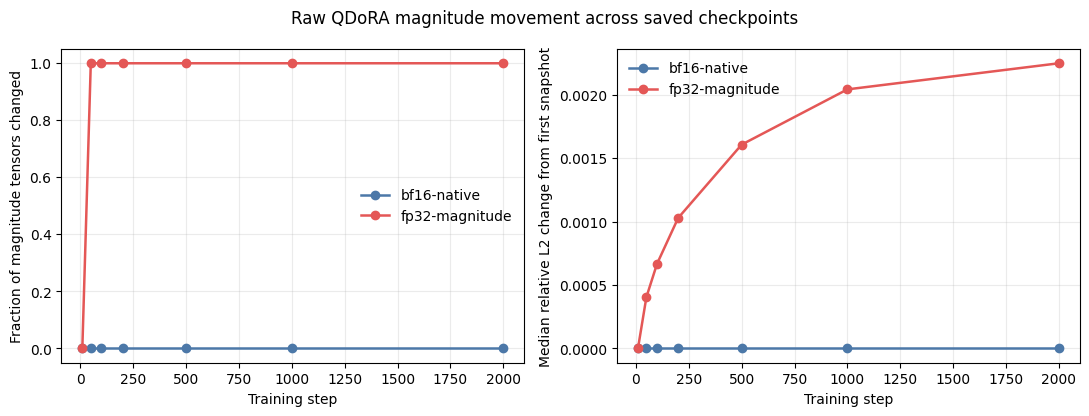

In [17]:
colors = {"bf16-native": "#4C78A8", "fp32-magnitude": "#E45756"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for run, subset in magnitude_trajectory.groupby("run"):
    subset = subset.sort_values("step")
    axes[0].plot(
        subset["step"], subset["changed_tensor_fraction"],
        marker="o", linewidth=1.8, color=colors[run], label=run,
    )
    axes[1].plot(
        subset["step"], subset["median_relative_l2_delta"],
        marker="o", linewidth=1.8, color=colors[run], label=run,
    )

axes[0].set_ylabel("Fraction of magnitude tensors changed")
axes[1].set_ylabel("Median relative L2 change from first snapshot")
for axis in axes:
    axis.set_xlabel("Training step")
    axis.grid(alpha=0.25)
    axis.legend(frameon=False)

fig.suptitle("Raw QDoRA magnitude movement across saved checkpoints")
fig.tight_layout()
# fig.savefig(OUT / "qdora_magnitude_movement.png", dpi=200, bbox_inches="tight")
fig.savefig(OUT / "qdora_magnitude_movement.pdf", bbox_inches="tight")
plt.show()


## 5. Verify dtype, trainability, and gradients



In [18]:
audit_rows = []
gradient_rows = []
optimizer_update_rows = []

for run, repo_dir in RUNS.items():
    audit_path = f"{repo_dir}/metrics/magnitude_audit.json"
    assert audit_path in REPO_FILES, f"Missing {REPO_ID}/{audit_path}"
    audit = read_remote_json(REPO_ID, audit_path)
    params = audit.get("params", [])
    dtype_counts = Counter(param.get("dtype") for param in params)
    audit_rows.append({
        "run": run,
        "n_magnitude_tensors": len(params),
        "n_trainable": sum(bool(param.get("requires_grad")) for param in params),
        "n_frozen": sum(not bool(param.get("requires_grad")) for param in params),
        "dtype_counts": dict(dtype_counts),
    })

    gradient_path = f"{repo_dir}/metrics/magnitude_grad_norms.jsonl"
    assert gradient_path in REPO_FILES, f"Missing {REPO_ID}/{gradient_path}"
    for payload in read_remote_jsonl(REPO_ID, gradient_path):
        records = payload.get("magnitude_params", [])
        norms = [record.get("grad_l2_norm") for record in records]
        gradient_rows.append({
            "run": run,
            "step": int(payload["step"]),
            "n_tensors": len(records),
            "all_have_grad": bool(payload.get("all_have_grad")),
            "nonzero_grad_tensor_fraction": float(np.mean([
                norm is not None and np.isfinite(norm) and norm > 0 for norm in norms
            ])),
            "median_grad_l2_norm": float(np.median([
                norm for norm in norms if norm is not None and np.isfinite(norm)
            ])),
            "parameter_dtypes": ",".join(sorted({
                record.get("dtype", "unknown") for record in records
            })),
        })


audit_summary = pd.DataFrame(audit_rows)
gradient_detail = pd.DataFrame(gradient_rows)
gradient_summary = (
    gradient_detail.groupby("run", as_index=False)
    .agg(
        logged_steps=("step", "nunique"),
        n_tensors_min=("n_tensors", "min"),
        all_have_grad_every_log=("all_have_grad", "all"),
        minimum_nonzero_grad_tensor_fraction=("nonzero_grad_tensor_fraction", "min"),
        median_grad_l2_norm=("median_grad_l2_norm", "median"),
        parameter_dtypes=("parameter_dtypes", lambda x: ",".join(sorted(set(x)))),
    )
)

display(audit_summary)
display(gradient_summary)
audit_summary.to_csv(OUT / "magnitude_audit_summary.csv", index=False)
gradient_summary.to_csv(OUT / "magnitude_gradient_summary.csv", index=False)


,run,n_magnitude_tensors,n_trainable,n_frozen,dtype_counts
0,bf16-native,160,160,0,{'torch.bfloat16': 160}
1,fp32-magnitude,160,160,0,{'torch.float32': 160}


,run,logged_steps,n_tensors_min,all_have_grad_every_log,minimum_nonzero_grad_tensor_fraction,median_grad_l2_norm,parameter_dtypes
0,bf16-native,200,160,True,1.0,0.005073,torch.bfloat16
1,fp32-magnitude,200,160,True,1.0,0.005054,torch.float32
